# SPAM: Scalable Polynomial Additive Model

SPAM represents homogeneous polynomial blocks with low-rank projections, avoiding explicit construction of every polynomial coefficient tensor.


## Model in one view


For degree $q$ and rank $R_q$,

$$
p_q(x)=\sum_{r=1}^{R_q}\alpha_{qr}(w_{qr}^{\top}x)^q,
\qquad
\eta(x)=\beta_0+u(x)+\sum_{q=2}^{Q}p_q(x),
$$

where $u(x)$ contains unary effects and diagonal corrections.



SPAM approximates high-order polynomial coefficient tensors with sums of
rank-one factors. A rank-$R$ degree-$q$ block therefore scales with $R$ times
the input dimension instead of the full $d^q$ tensor. Unary and diagonal
corrections separate lower-order effects from distinct-variable interactions.

The low-rank factorization is efficient but its factors are not individually
identifiable: permutations and compensating rescalings can describe the same
polynomial. Interpretation should use the reconstructed local terms exposed by
`local_term_importance`, rather than raw factor weights.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 180
X = pd.DataFrame({
    "x1": rng.uniform(-1.0, 1.0, n),
    "x2": rng.normal(size=n),
    "group": rng.choice(["a", "b", "c"], size=n),
})
y = (
    np.sin(np.pi * X["x1"])
    + 0.35 * X["x2"] ** 2
    + 0.30 * (X["group"] == "b")
    + rng.normal(0.0, 0.12, n)
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)


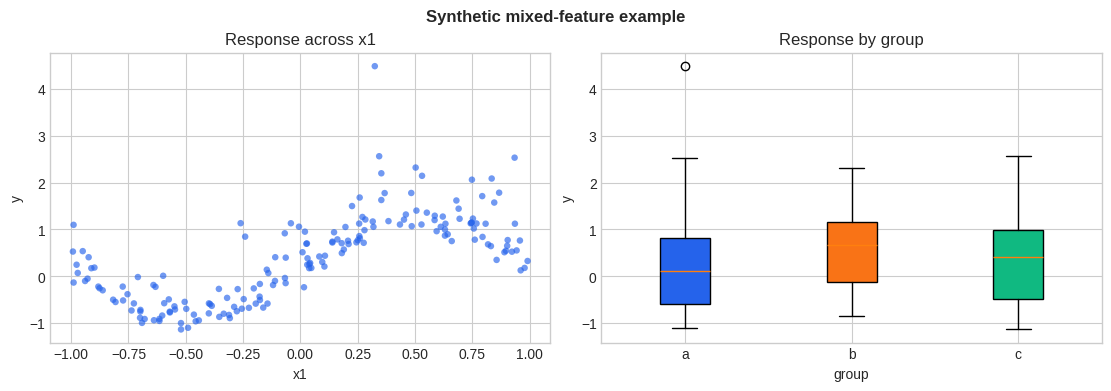

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(X["x1"], y, s=22, alpha=0.65, color=COLORS[0], edgecolor="none")
axes[0].set(title="Response across x1", xlabel="x1", ylabel="y")

group_order = ["a", "b", "c"]
group_values = [y[X["group"].to_numpy() == level] for level in group_order]
boxes = axes[1].boxplot(group_values, tick_labels=group_order, patch_artist=True)
for patch, color in zip(boxes["boxes"], COLORS, strict=False):
    patch.set_facecolor(color)
axes[1].set(title="Response by group", xlabel="group", ylabel="y")
fig.suptitle("Synthetic mixed-feature example", fontweight="bold")
plt.show()
plt.close(fig)


## Fit the model


In [3]:
from nampy.models import SPAMClassifier, SPAMLSS, SPAMRegressor


model = SPAMRegressor(
    ranks=[16, 8],       # ranks for degrees 2 and 3
    reg_order=2,
    regularization_scale=1e-5,
    basis_l1_regularization=0.0,
    use_geometric_mean=True,
)
model.get_params(deep=False)


{'basis_l1_regularization': 0.0,
 'dropout': 0.0,
 'ignore_unary': False,
 'intercept': True,
 'lower_order_correction': False,
 'lr': 0.001,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'orthogonal': False,
 'proximal': False,
 'ranks': [16, 8],
 'reg_order': 2,
 'regularization_scale': 1e-05,
 'use_geometric_mean': True,
 'weight_decay': 0.0,
 'feature_preprocessing': None,
 'n_bins': 64,
 'numerical_preprocessing': 'none',
 'categorical_preprocessing': 'one-hot',
 'use_decision_tree_bins': False,
 'binning_strategy': 'uniform',
 'task': 'regression',
 'cat_cutoff': 0.03,
 'treat_all_integers_as_numerical': False,
 'degree': 3,
 'scaling_strategy': 'minmax',
 'n_knots': 64,
 'use_decision_tree_knots': True,
 'knots_strategy': 'uniform',
 'spline_implementation': 'sklearn',
 'min_unique_vals': 5}

In [4]:
model.fit(
    X_train,
    y_train,
    max_epochs=3,
    batch_size=64,
    random_state=7,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
predictions = model.predict(X_test)
r2 = model.score(X_test, y_test)
metrics = model.evaluate(X_test, y_test)
components = model.predict_components(X_test)
explanation = model.explain_terms(X_test, max_bins=24, center=True)
importance = model.term_importance(X_test, center=True)
interaction_importance = model.interaction_importance(X_test, center=True)
display({"R2": r2, **metrics})
display(importance)
display(explanation.head(12))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/core/m

{'R2': -0.38480720972253857, 'Mean Squared Error': 0.9664682571407158}

,term,term_type,output,importance
0,group[1],main,0,0.043318
1,group[0],main,0,0.042767
2,degree_2,main,0,0.039414
3,degree_3,main,0,0.033559
4,x1,main,0,0.021509
5,group[2],main,0,0.021424
6,x2,main,0,0.021139


,term,term_type,output,value,contribution,count,importance
0,x1,main,0,-0.965,-0.045021,2,0.021509
1,x1,main,0,-0.8895,-0.043513,2,0.021509
2,x1,main,0,-0.7905,-0.036379,2,0.021509
3,x1,main,0,-0.6915,-0.032679,2,0.021509
4,x1,main,0,-0.58,-0.027745,2,0.021509
5,x1,main,0,-0.4875,-0.022332,2,0.021509
6,x1,main,0,-0.35,-0.014141,1,0.021509
7,x1,main,0,-0.209,-0.012598,2,0.021509
8,x1,main,0,-0.12505,-0.008328,2,0.021509
9,x1,main,0,-0.05205,-0.005221,2,0.021509


## Evaluate and explain


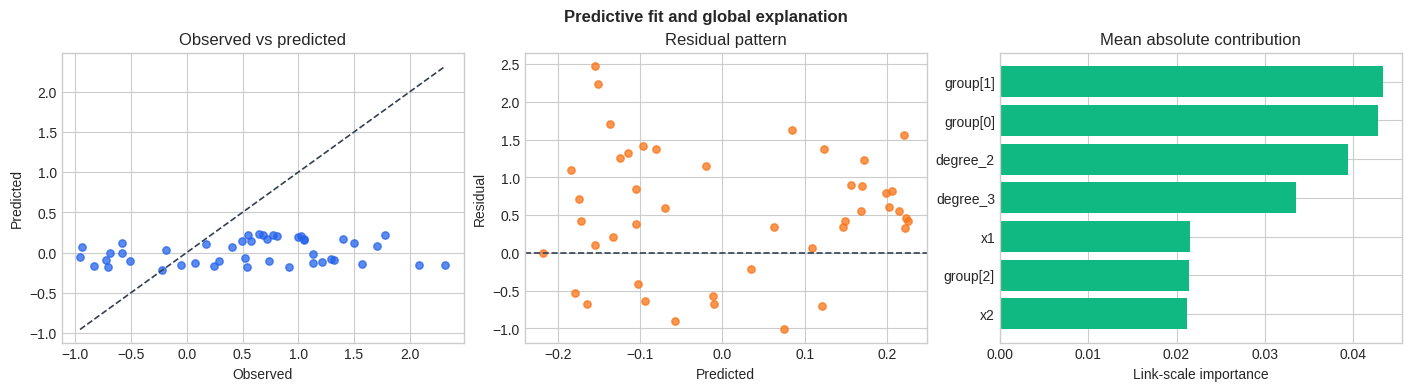

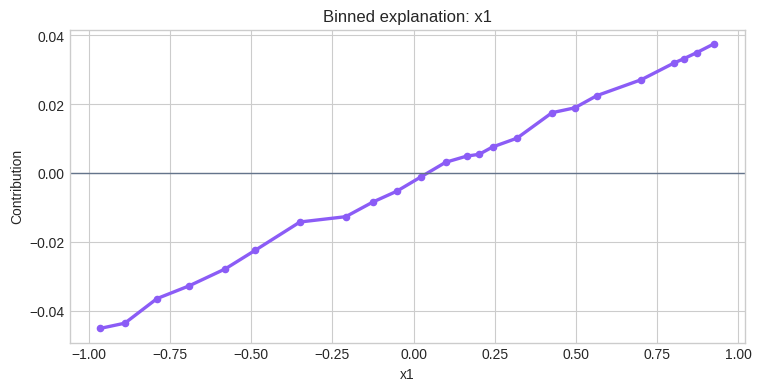

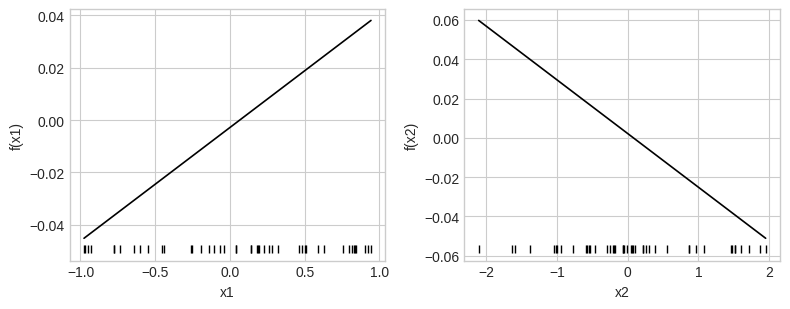

In [5]:
observed = np.asarray(y_test).reshape(-1)
fitted = np.asarray(predictions).reshape(-1)
residual = observed - fitted

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].scatter(observed, fitted, s=28, alpha=0.75, color=COLORS[0])
lo = min(observed.min(), fitted.min())
hi = max(observed.max(), fitted.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#334155", linewidth=1.2)
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(fitted, residual, s=28, alpha=0.75, color=COLORS[1])
axes[1].axhline(0.0, color="#334155", linestyle="--", linewidth=1.2)
axes[1].set(title="Residual pattern", xlabel="Predicted", ylabel="Residual")

importance_plot = (
    importance.groupby("term", as_index=False)["importance"]
    .mean()
    .sort_values("importance")
)
axes[2].barh(importance_plot["term"], importance_plot["importance"], color=COLORS[2])
axes[2].set(title="Mean absolute contribution", xlabel="Link-scale importance")
fig.suptitle("Predictive fit and global explanation", fontweight="bold")
plt.show()
plt.close(fig)

main_effects = explanation.loc[
    (explanation["term_type"] == "main") & (explanation["output"] == 0)
].copy()
main_effects["numeric_value"] = pd.to_numeric(main_effects["value"], errors="coerce")
main_effects = main_effects.dropna(subset=["numeric_value"])
if not main_effects.empty:
    numeric_terms = set(main_effects["term"])
    top_term = next(
        term
        for term in importance_plot.sort_values("importance", ascending=False)["term"]
        if term in numeric_terms
    )
    curve = main_effects.loc[main_effects["term"] == top_term].sort_values("numeric_value")
    if not curve.empty:
        fig, ax = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
        ax.plot(curve["numeric_value"], curve["contribution"], color=COLORS[3], linewidth=2.4)
        ax.scatter(curve["numeric_value"], curve["contribution"], s=20, color=COLORS[3])
        ax.axhline(0.0, color="#64748B", linewidth=1)
        ax.set(title=f"Binned explanation: {top_term}", xlabel=top_term, ylabel="Contribution")
        plt.show()
        plt.close(fig)

term_figures = model.plot_terms(X_test, center=True, rug=True, pages=1)
interaction_terms = interaction_importance["term"].astype(str).tolist()
interactions_are_raw_columns = all(
    all(
        part in X_test.columns
        and pd.api.types.is_numeric_dtype(X_test[part])
        for part in term.split(":")
    )
    for term in interaction_terms
)
if interaction_terms and interactions_are_raw_columns:
    model.plot_interactions(X_test)


## Model-specific controls

`local_term_importance` expands the low-rank representation into sample-specific unary and distinct-variable polynomial terms.


In [6]:
local = model.local_term_importance(X_test.iloc[:5], top_k=5)
display(local[0])
display(model.term_importance(X_test))


[{'term': ('group[1]',), 'order': 1, 'contribution': -0.06983146513812244},
 {'term': ('x2',), 'order': 1, 'contribution': -0.018372928956523538},
 {'term': ('x2', 'group[1]'),
  'order': 2,
  'contribution': -0.012425677850842476},
 {'term': ('x1', 'group[1]'),
  'order': 2,
  'contribution': 0.005734204780310392},
 {'term': ('x1', 'x2'), 'order': 2, 'contribution': -0.0023737610317766666}]

,term,term_type,output,importance
0,degree_2,main,0,0.039717
1,degree_3,main,0,0.033853
2,group[1],main,0,0.032489
3,group[0],main,0,0.027493
4,x2,main,0,0.026228
5,x1,main,0,0.021859
6,group[2],main,0,0.019281


## Supported task variants

`SPAMRegressor`, `SPAMClassifier`, and `SPAMLSS` share the same polynomial basis and regularization controls.


In [7]:
task_variants = {"regression": SPAMRegressor(), "classification": SPAMClassifier(), "distributional": SPAMLSS()}


## References

- [Scalable Polynomial Additive Models (2022)](https://arxiv.org/abs/2205.14108).
